# **Phase 3 — Speech Emotion Recognition Pipeline**

This phase focuses on building a deep learning framework for recognizing emotions directly from speech signals.

The speech pipeline includes:

- audio preprocessing
- MFCC feature extraction
- temporal acoustic modelling
- attention-based emotional representation learning
- emotion classification

The architecture combines:

- Convolutional Neural Networks (CNN)
- Bidirectional Long Short-Term Memory Networks (BiLSTM)
- Attention Mechanism

This hybrid architecture enables the model to learn both:

- local acoustic structures
- long-term emotional dependencies

# Importing Required Libraries

This section imports all libraries required for:

- speech processing
- feature extraction
- deep learning
- visualization
- evaluation

In [6]:
import os
import pickle

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.manifold import TSNE

# Loading Metadata and Label Encoder

The processed metadata and label encoder generated during dataset preparation are loaded to maintain consistency across all training pipelines.

The metadata dataframe contains:

- audio file paths
- transcript text
- emotion labels
- speaker information

The label encoder preserves the mapping between categorical emotions and numerical labels.

In [7]:
import os
import pickle
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition"
metadata_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "tess_metadata.csv"
)
label_encoder_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "label_encoder.pkl"
)

# Load Metadata
df = pd.read_csv(metadata_path)

# Load Label Encoder
with open(label_encoder_path, "rb") as file:
    label_encoder = pickle.load(file)
print("Metadata Loaded Successfully")
print()
print("Dataset Shape:")
print(df.shape)

Metadata Loaded Successfully

Dataset Shape:
(2800, 5)


# Creating Train / Validation / Test Splits

To ensure robust experimentation, the dataset is divided into:

- training set
- validation set
- test set

The split is performed using stratified sampling to preserve balanced emotion distribution across all subsets.

In [8]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)
print("Dataset Split Completed")
print()
print("Training Samples:", len(train_df))
print("Validation Samples:", len(val_df))
print("Test Samples:", len(test_df))

Dataset Split Completed

Training Samples: 2023
Validation Samples: 357
Test Samples: 420


# Configuring GPU Device

Deep learning training is accelerated using CUDA-enabled GPU support available in Google Colab.

In [9]:
import torch
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print("Using Device:", device)

Using Device: cuda


# Speech Feature Extraction Strategy

Emotion recognition from speech requires extracting informative acoustic representations.

The following features are used:

### MFCC Features
Capture spectral speech characteristics

### Delta Features
Capture temporal changes in speech

### Delta-Delta Features
Capture acceleration and dynamic emotional variations

Combining all three improves emotional representation learning.

# Audio Preprocessing and Acoustic Feature Extraction

This section performs:

- audio loading
- silence trimming
- normalization
- MFCC extraction
- temporal feature extraction
- feature padding

The final output is a fixed-size feature representation suitable for deep learning models.

In [10]:
import librosa
import numpy as np

SAMPLE_RATE = 22050
MAX_PAD_LENGTH = 200
N_MFCC = 40

def extract_speech_features(audio_path):

    # Load Audio
    signal, sample_rate = librosa.load(
        audio_path,
        sr=SAMPLE_RATE
    )

    # Remove Silence
    signal, _ = librosa.effects.trim(
        signal
    )

    # Normalize Signal
    signal = librosa.util.normalize(
        signal
    )

    # MFCC Features
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=N_MFCC
    )

    # First-Order Delta
    delta_mfcc = librosa.feature.delta(
        mfcc
    )

    # Second-Order Delta
    delta2_mfcc = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Combine Features
    combined_features = np.vstack([
        mfcc,
        delta_mfcc,
        delta2_mfcc
    ])

    # Padding / Truncation
    if combined_features.shape[1] < MAX_PAD_LENGTH:
        pad_width = (
            MAX_PAD_LENGTH -
            combined_features.shape[1]
        )
        combined_features = np.pad(
            combined_features,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )
    else:
        combined_features = combined_features[
            :,
            :MAX_PAD_LENGTH
        ]
    return combined_features.T

# Verifying Acoustic Feature Extraction

This section validates whether the extracted speech representation maintains the expected dimensional consistency required for neural network training.

In [11]:
sample_audio_path = train_df.iloc[0]["audio_path"]
sample_features = extract_speech_features(
    sample_audio_path
)
print("Feature Shape:")
print(sample_features.shape)

Feature Shape:
(200, 120)


# Visualizing Acoustic Feature Representation

This visualization displays the extracted speech representation used for emotion learning.

The heatmap illustrates:

- spectral structures
- temporal variations
- emotional acoustic patterns

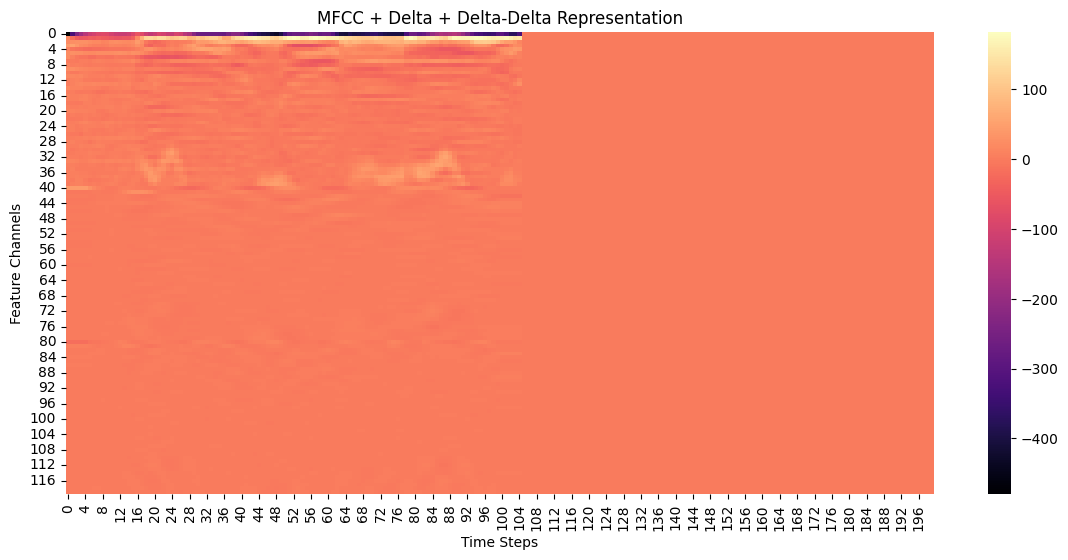

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.heatmap(
    sample_features.T,
    cmap="magma"
)
plt.title("MFCC + Delta + Delta-Delta Representation")
plt.xlabel("Time Steps")
plt.ylabel("Feature Channels")
plt.show()

# Creating Custom Speech Dataset

A custom PyTorch dataset is implemented for:

- dynamic feature extraction
- efficient batch generation
- scalable GPU-based training

In [13]:
from torch.utils.data import Dataset

class SpeechEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(
            drop=True
        )
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        audio_path = row["audio_path"]
        label = row["label"]

        # Extract Features
        features = extract_speech_features(
            audio_path
        )

        # Convert To Tensor
        features_tensor = torch.tensor(
            features,
            dtype=torch.float32
        )
        label_tensor = torch.tensor(
            label,
            dtype=torch.long
        )
        return features_tensor, label_tensor

# Creating Speech Datasets

Separate dataset objects are created for:

- training
- validation
- testing

This separation ensures clean experimentation and unbiased evaluation.

In [14]:
train_dataset = SpeechEmotionDataset(
    train_df
)

val_dataset = SpeechEmotionDataset(
    val_df
)

test_dataset = SpeechEmotionDataset(
    test_df
)

print("Speech Datasets Created Successfully")

Speech Datasets Created Successfully


# Creating DataLoaders

PyTorch DataLoaders enable:

- mini-batch training
- shuffled sampling
- efficient GPU utilization
- scalable data iteration

In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Created Successfully")

DataLoaders Created Successfully


# Verifying Batch Dimensions

This step validates whether generated batches maintain the expected dimensions required for neural network processing.

In [16]:
for features, labels in train_loader:
    print("Feature Batch Shape:")
    print(features.shape)
    print()
    print("Label Batch Shape:")
    print(labels.shape)
    break

Feature Batch Shape:
torch.Size([16, 200, 120])

Label Batch Shape:
torch.Size([16])


# **Designing the Speech Emotion Recognition Architecture**

The speech model combines:

- Convolutional Neural Networks (CNN)
- Bidirectional Long Short-Term Memory Networks (BiLSTM)
- Attention Mechanism

### CNN Layers
Learn local acoustic structures

### BiLSTM Layers
Capture temporal emotional dependencies

### Attention Mechanism
Identify emotionally important speech regions

The combined architecture enables robust emotional representation learning from acoustic signals.

# Implementing Attention Mechanism

Attention mechanisms allow the model to focus on emotionally important temporal regions in speech sequences.

Instead of treating all time frames equally, attention dynamically assigns higher importance to emotionally informative frames.

In [17]:
class AttentionLayer(nn.Module):

    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(
            hidden_dim,
            1
        )
    def forward(self, lstm_output):

        # Compute Attention Scores
        attention_scores = self.attention_weights(
            lstm_output
        )

        # Normalize Scores
        attention_scores = torch.softmax(
            attention_scores,
            dim=1
        )

        # Weighted Sum
        context_vector = torch.sum(
            attention_scores * lstm_output,
            dim=1
        )

        return context_vector

# Building CNN + BiLSTM + Attention Model

The final speech architecture performs:

1. Convolutional acoustic feature extraction
2. Temporal emotional sequence modelling
3. Attention-based emotional focus
4. Emotion classification

The model also produces intermediate emotional embeddings that will later be used for multimodal fusion learning.

In [18]:
class AdvancedSpeechEmotionModel(nn.Module):

    def __init__(self):

        super(
            AdvancedSpeechEmotionModel,
            self
        ).__init__()

        # --------------------------------------------------
        # CNN FEATURE EXTRACTION
        # --------------------------------------------------

        self.conv1 = nn.Conv1d(
            in_channels=120,
            out_channels=128,
            kernel_size=3,
            padding=1
        )
        self.batch_norm1 = nn.BatchNorm1d(
            128
        )
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(
            kernel_size=2
        )
        self.dropout = nn.Dropout(
            0.3
        )

        # --------------------------------------------------
        # BiLSTM TEMPORAL MODELLING
        # --------------------------------------------------

        self.bilstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # --------------------------------------------------
        # ATTENTION MECHANISM
        # --------------------------------------------------

        self.attention = AttentionLayer(
            hidden_dim=256
        )

        # --------------------------------------------------
        # DENSE LAYERS
        # --------------------------------------------------

        self.fc1 = nn.Linear(
            256,
            128
        )
        self.fc2 = nn.Linear(
            128,
            7
        )
    def forward(self, x):

        # ----------------------------------------------
        # INPUT SHAPE
        # (batch, time_steps, features)
        # ----------------------------------------------

        x = x.permute(
            0,
            2,
            1
        )

        # ----------------------------------------------
        # CNN
        # ----------------------------------------------

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.dropout(x)

        # ----------------------------------------------
        # PREPARE FOR LSTM
        # ----------------------------------------------

        x = x.permute(
            0,
            2,
            1
        )

        # ----------------------------------------------
        # BiLSTM
        # ----------------------------------------------

        lstm_output, _ = self.bilstm(x)

        # ----------------------------------------------
        # ATTENTION
        # ----------------------------------------------

        attention_output = self.attention(
            lstm_output
        )

        # ----------------------------------------------
        # EMOTION EMBEDDING
        # ----------------------------------------------

        embedding = self.fc1(
            attention_output
        )

        embedding = self.relu(
            embedding
        )

        embedding = self.dropout(
            embedding
        )

        # ----------------------------------------------
        # CLASSIFICATION
        # ----------------------------------------------

        logits = self.fc2(
            embedding
        )

        return logits, embedding

# Initializing the Speech Emotion Recognition Model

The model is initialized and transferred to GPU memory for accelerated deep learning training.

In [19]:
speech_model = AdvancedSpeechEmotionModel().to(
    device
)

print(speech_model)

AdvancedSpeechEmotionModel(
  (conv1): Conv1d(120, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (batch_norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention_weights): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)


# Verifying Forward Propagation

This section validates whether the model successfully processes mini-batches and produces:

- emotion predictions
- intermediate emotional embeddings

In [20]:
for features, labels in train_loader:

    features = features.to(device)
    logits, embeddings = speech_model(
        features
    )

    print("Input Shape:")
    print(features.shape)
    print()
    print("Logits Shape:")
    print(logits.shape)
    print()
    print("Embedding Shape:")
    print(embeddings.shape)
    break

Input Shape:
torch.Size([16, 200, 120])

Logits Shape:
torch.Size([16, 7])

Embedding Shape:
torch.Size([16, 128])


# Counting Model Parameters

Model parameter analysis helps estimate:

- model complexity
- memory usage
- computational requirements

In [21]:
total_parameters = sum(
    parameter.numel()
    for parameter in speech_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in speech_model.parameters()
    if parameter.requires_grad
)

print("Total Parameters:")
print(total_parameters)
print()
print("Trainable Parameters:")
print(trainable_parameters)

Total Parameters:
739976

Trainable Parameters:
739976


# Understanding the Speech Pipeline

The final speech architecture performs:

1. Local acoustic feature extraction using CNN
2. Temporal sequence learning using BiLSTM
3. Emotional frame weighting using attention
4. Emotional embedding generation
5. Emotion classification

This architecture enables robust learning of emotional acoustic patterns from speech signals.

# **Understanding the Speech Pipeline**

The final speech architecture performs:

1. Local acoustic feature extraction using CNN
2. Temporal sequence learning using BiLSTM
3. Emotional frame weighting using attention
4. Emotional embedding generation
5. Emotion classification

This architecture enables robust learning of emotional acoustic patterns from speech signals.

# Configuring Training Components

The speech emotion recognition model requires:

- loss function
- optimizer
- learning rate scheduler

These components control:

- model optimization
- convergence speed
- training stability

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    speech_model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print("Training Components Initialized")

Training Components Initialized


# Defining Evaluation Metrics

The following metrics are used for performance evaluation:

### Accuracy
Measures overall prediction correctness

### Weighted F1-Score
Provides balanced evaluation across all emotion classes

Weighted F1-score is particularly important for emotional classification tasks.

In [23]:
from sklearn.metrics import f1_score

print("Evaluation Metrics Ready")

Evaluation Metrics Ready


# Initializing Training History Containers

Training history is stored for:

- loss visualization
- accuracy visualization
- convergence analysis

In [24]:
train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []

train_f1_scores = []

val_f1_scores = []

# Configuring Early Stopping

Early stopping prevents unnecessary overtraining by monitoring validation loss.

If validation performance stops improving, training is automatically terminated.

In [25]:
BEST_MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "saved_models",
    "advanced_speech_emotion_model.pth"
)
best_validation_loss = float("inf")
early_stopping_counter = 0
EARLY_STOPPING_PATIENCE = 5

# Configuring Training Duration

The speech model will be trained for multiple epochs while monitoring validation performance.

In [26]:
EPOCHS = 30
print("Training Epochs:", EPOCHS)

Training Epochs: 30


# Training the Speech Emotion Recognition Model

This training pipeline performs:

- forward propagation
- loss computation
- backpropagation
- gradient clipping
- validation monitoring
- checkpoint saving
- learning rate scheduling

The model with the best validation performance is automatically saved.

In [27]:
for epoch in range(EPOCHS):

    # ==================================================
    # TRAINING PHASE
    # ==================================================

    speech_model.train()
    total_train_loss = 0
    train_predictions = []
    train_labels = []

    for features, labels in train_loader:

        # Move To GPU
        features = features.to(device)
        labels = labels.to(device)

        # Reset Gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs, embeddings = speech_model(
            features
        )

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            speech_model.parameters(),
            max_norm=5
        )

        # Update Parameters
        optimizer.step()

        # Accumulate Loss
        total_train_loss += loss.item()

        # Predictions
        predictions = torch.argmax(
            outputs,
            dim=1
        )
        train_predictions.extend(
            predictions.cpu().numpy()
        )
        train_labels.extend(
            labels.cpu().numpy()
        )

    # ==================================================
    # TRAINING METRICS
    # ==================================================

    average_train_loss = (
        total_train_loss /
        len(train_loader)
    )

    train_accuracy = accuracy_score(
        train_labels,
        train_predictions
    )
    train_f1 = f1_score(
        train_labels,
        train_predictions,
        average='weighted'
    )

    # ==================================================
    # VALIDATION PHASE
    # ==================================================

    speech_model.eval()
    total_val_loss = 0
    val_predictions = []
    val_labels = []
    with torch.no_grad():
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            outputs, embeddings = speech_model(
                features
            )
            loss = criterion(
                outputs,
                labels
            )
            total_val_loss += loss.item()
            predictions = torch.argmax(
                outputs,
                dim=1
            )
            val_predictions.extend(
                predictions.cpu().numpy()
            )
            val_labels.extend(
                labels.cpu().numpy()
            )

    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    average_val_loss = (
        total_val_loss /
        len(val_loader)
    )
    val_accuracy = accuracy_score(
        val_labels,
        val_predictions
    )
    val_f1 = f1_score(
        val_labels,
        val_predictions,
        average='weighted'
    )

    # ==================================================
    # STORE HISTORY
    # ==================================================

    train_losses.append(
        average_train_loss
    )
    val_losses.append(
        average_val_loss
    )
    train_accuracies.append(
        train_accuracy
    )
    val_accuracies.append(
        val_accuracy
    )
    train_f1_scores.append(
        train_f1
    )
    val_f1_scores.append(
        val_f1
    )

    # ==================================================
    # LEARNING RATE SCHEDULER
    # ==================================================

    scheduler.step(
        average_val_loss
    )

    # ==================================================
    # MODEL CHECKPOINT
    # ==================================================

    if average_val_loss < best_validation_loss:
        best_validation_loss = average_val_loss
        early_stopping_counter = 0
        torch.save(
            speech_model.state_dict(),
            BEST_MODEL_PATH
        )
        print("Best Model Saved")
    else:
        early_stopping_counter += 1

    # ==================================================
    # EPOCH RESULTS
    # ==================================================

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {average_train_loss:.4f}")
    print(f"Validation Loss: {average_val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy*100:.2f}%")
    print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
    print(f"Train F1-Score: {train_f1:.4f}")
    print(f"Validation F1-Score: {val_f1:.4f}")
    print("-" * 50)

    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
        print("\nEarly Stopping Triggered")
        break

Best Model Saved

Epoch [1/30]
Train Loss: 0.6292
Validation Loss: 0.2455
Train Accuracy: 77.06%
Validation Accuracy: 91.88%
Train F1-Score: 0.7707
Validation F1-Score: 0.9114
--------------------------------------------------
Best Model Saved

Epoch [2/30]
Train Loss: 0.0808
Validation Loss: 0.0118
Train Accuracy: 97.48%
Validation Accuracy: 99.44%
Train F1-Score: 0.9748
Validation F1-Score: 0.9944
--------------------------------------------------
Best Model Saved

Epoch [3/30]
Train Loss: 0.0354
Validation Loss: 0.0049
Train Accuracy: 99.16%
Validation Accuracy: 100.00%
Train F1-Score: 0.9916
Validation F1-Score: 1.0000
--------------------------------------------------

Epoch [4/30]
Train Loss: 0.0161
Validation Loss: 0.0152
Train Accuracy: 99.56%
Validation Accuracy: 99.44%
Train F1-Score: 0.9955
Validation F1-Score: 0.9944
--------------------------------------------------
Best Model Saved

Epoch [5/30]
Train Loss: 0.0056
Validation Loss: 0.0002
Train Accuracy: 99.90%
Validation 

# Loading Best Model Checkpoint

The best-performing model based on validation loss is loaded for final evaluation.

In [28]:
speech_model.load_state_dict(
    torch.load(BEST_MODEL_PATH)
)
speech_model.eval()
print("Best Speech Model Loaded Successfully")

Best Speech Model Loaded Successfully


# Visualizing Training Convergence

Training curves help analyze:

- convergence stability
- overfitting behavior
- learning progression

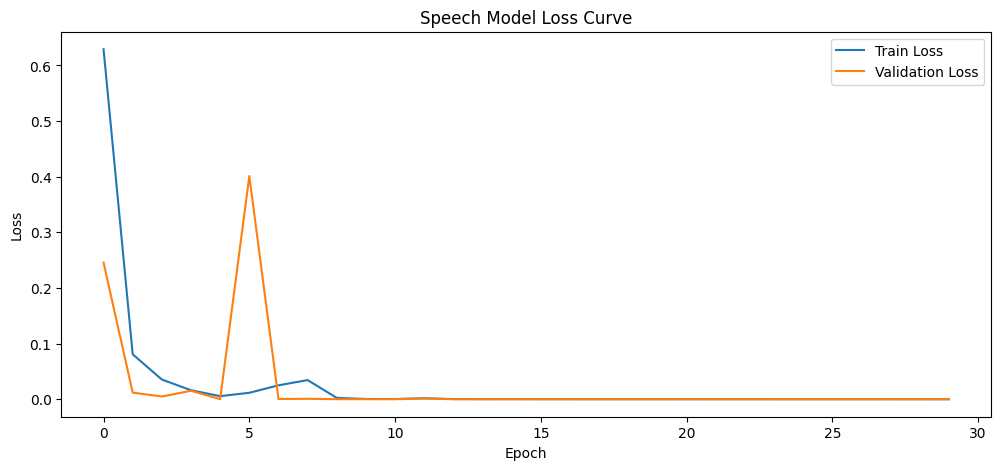

In [29]:
plt.figure(figsize=(12,5))
plt.plot(
    train_losses,
    label="Train Loss"
)
plt.plot(
    val_losses,
    label="Validation Loss"
)
plt.title("Speech Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualizing Accuracy Progression

This visualization illustrates how prediction performance improves throughout training.

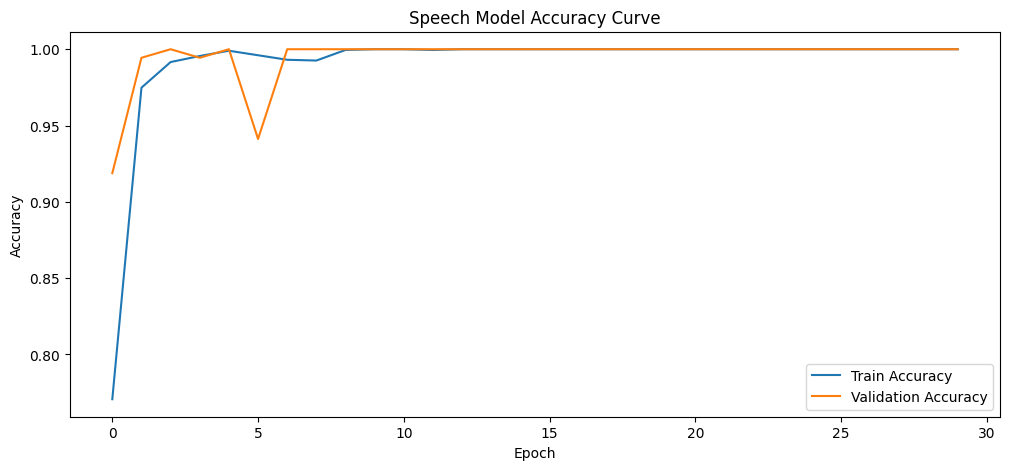

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)
plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.title("Speech Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Speech Pipeline Summary

The speech emotion recognition pipeline successfully implemented:

- advanced acoustic preprocessing
- MFCC + delta feature extraction
- CNN-based feature learning
- BiLSTM temporal modelling
- attention-based emotional focus
- validation-aware training
- early stopping
- checkpoint saving

The trained speech embeddings will later be used for multimodal fusion learning.

# **Phase 4 — Speech Model Evaluation and Embedding Analysis**

This phase evaluates the performance of the trained speech emotion recognition model using:

- test-set evaluation
- confusion matrix analysis
- classification metrics
- emotional embedding visualization

The learned speech embeddings are also analyzed using t-SNE dimensionality reduction to study emotional separability in latent feature space.

# Loading the Best Speech Model

The best-performing checkpoint obtained during validation-aware training is loaded for final evaluation on unseen test data.

In [31]:
speech_model.load_state_dict(
    torch.load(BEST_MODEL_PATH)
)
speech_model.eval()
print("Best Speech Model Loaded Successfully")

Best Speech Model Loaded Successfully


# Preparing Evaluation Containers

Prediction outputs, ground-truth labels, and emotional embeddings are collected for:

- performance evaluation
- visualization
- clustering analysis

In [32]:
test_predictions = []
test_labels = []
speech_embeddings = []

# Evaluating the Speech Emotion Recognition Model

The trained model is evaluated on unseen test samples to measure its generalization capability.

In [33]:
with torch.no_grad():

    for features, labels in test_loader:

        # Move To GPU
        features = features.to(device)
        labels = labels.to(device)

        # Forward Pass
        outputs, embeddings = speech_model(
            features
        )

        # Predictions
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Store Predictions
        test_predictions.extend(
            predictions.cpu().numpy()
        )

        # Store Labels
        test_labels.extend(
            labels.cpu().numpy()
        )

        # Store Embeddings
        speech_embeddings.extend(
            embeddings.cpu().numpy()
        )

print("Speech Model Evaluation Completed")

Speech Model Evaluation Completed


# Calculating Final Test Accuracy

Test accuracy measures the model’s ability to correctly classify unseen emotional speech samples.

In [34]:
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)
print("Final Speech Model Accuracy:")
print(f"{test_accuracy * 100:.2f}%")

Final Speech Model Accuracy:
99.76%


# Generating Classification Report

The classification report provides:

- precision
- recall
- F1-score

for each individual emotion category.

In [35]:
emotion_names = label_encoder.classes_
speech_report = classification_report(
    test_labels,
    test_predictions,
    target_names=emotion_names
)
print(speech_report)

              precision    recall  f1-score   support

       angry       1.00      0.98      0.99        60
     disgust       1.00      1.00      1.00        60
        fear       1.00      1.00      1.00        60
       happy       0.98      1.00      0.99        60
     neutral       1.00      1.00      1.00        60
          ps       1.00      1.00      1.00        60
         sad       1.00      1.00      1.00        60

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



# Constructing Confusion Matrix

The confusion matrix helps analyze:

- correctly classified emotions
- confused emotional categories
- class-wise prediction behavior

In [36]:
speech_confusion_matrix = confusion_matrix(
    test_labels,
    test_predictions
)
print(speech_confusion_matrix)

[[59  0  0  1  0  0  0]
 [ 0 60  0  0  0  0  0]
 [ 0  0 60  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  0  0  0  0 60  0]
 [ 0  0  0  0  0  0 60]]


# Visualizing Confusion Matrix

This visualization provides an interpretable overview of emotion-wise classification performance.

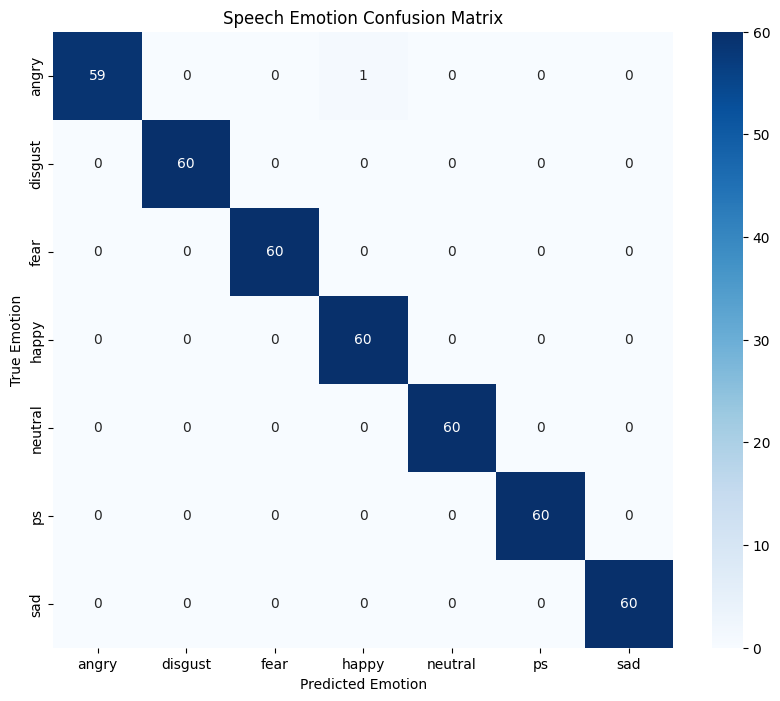

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    speech_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("Speech Emotion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Saving Confusion Matrix Visualization

The confusion matrix is saved for:

- report integration
- GitHub documentation
- presentation usage

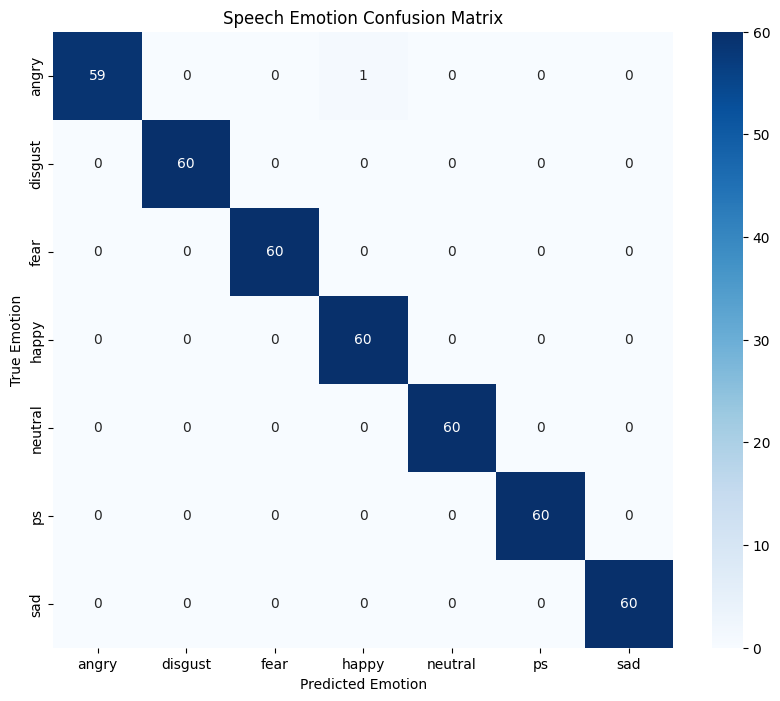

Confusion Matrix Saved Successfully


In [38]:
confusion_matrix_path = os.path.join(
    PROJECT_PATH,
    "results",
    "confusion_matrices",
    "speech_confusion_matrix.png"
)
plt.figure(figsize=(10,8))
sns.heatmap(
    speech_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title("Speech Emotion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.savefig(confusion_matrix_path)
plt.show()
print("Confusion Matrix Saved Successfully")

# Converting Emotional Embeddings into NumPy Format

The extracted emotional embeddings are converted into NumPy arrays for dimensionality reduction and clustering analysis.

In [39]:
speech_embeddings_array = np.array(
    speech_embeddings
)

test_labels_array = np.array(
    test_labels
)

print("Embedding Shape:")
print(speech_embeddings_array.shape)

Embedding Shape:
(420, 128)


# Applying t-SNE Dimensionality Reduction

t-SNE converts high-dimensional emotional embeddings into 2D space for visualization and emotional cluster analysis.

In [40]:
from sklearn.manifold import TSNE

speech_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

speech_embeddings_2d = speech_tsne.fit_transform(
    speech_embeddings_array
)
print("t-SNE Transformation Completed")

t-SNE Transformation Completed


# Visualizing Emotional Embedding Clusters

This visualization illustrates how different emotional categories are separated within the learned embedding space.

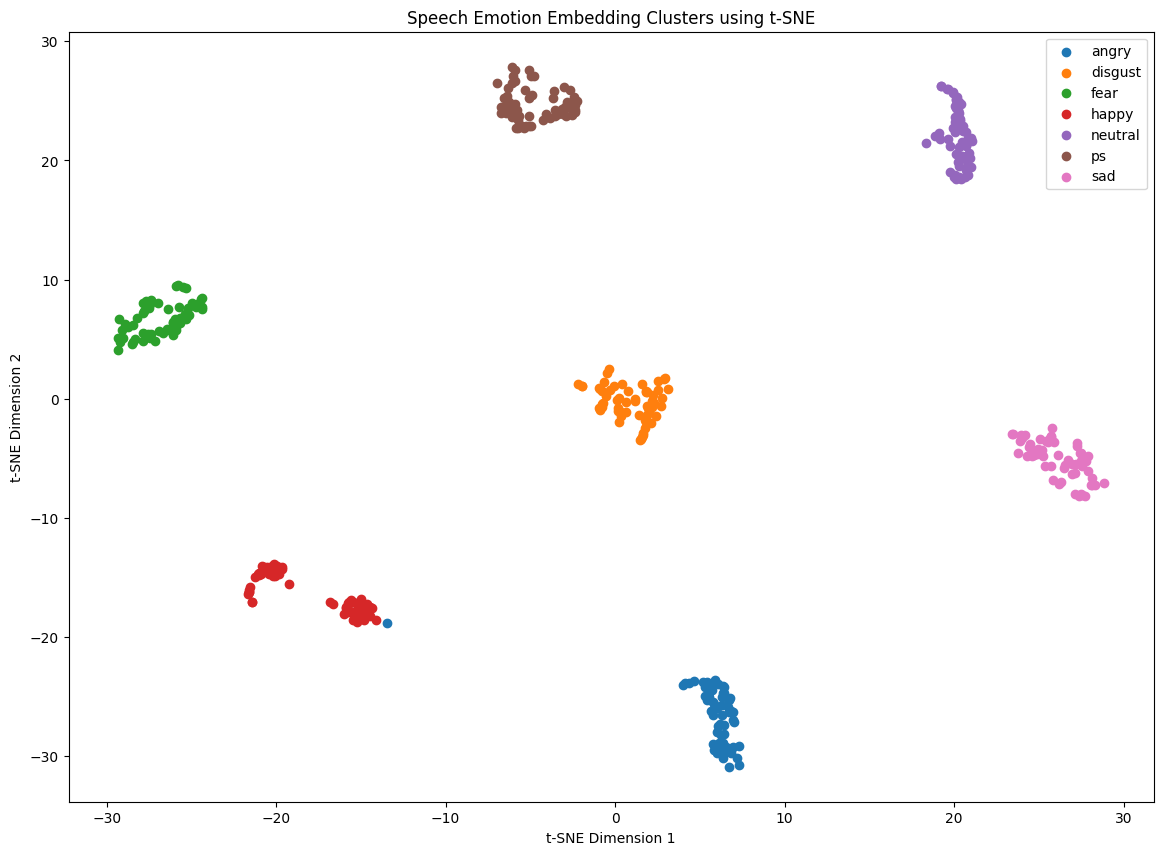

In [41]:
plt.figure(figsize=(14,10))

for label in np.unique(test_labels_array):
    indices = test_labels_array == label
    emotion_name = label_encoder.inverse_transform(
        [label]
    )[0]
    plt.scatter(
        speech_embeddings_2d[indices, 0],
        speech_embeddings_2d[indices, 1],
        label=emotion_name
    )

plt.title("Speech Emotion Embedding Clusters using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.show()

# Saving t-SNE Visualization

The emotional cluster visualization is saved for report documentation and GitHub presentation.

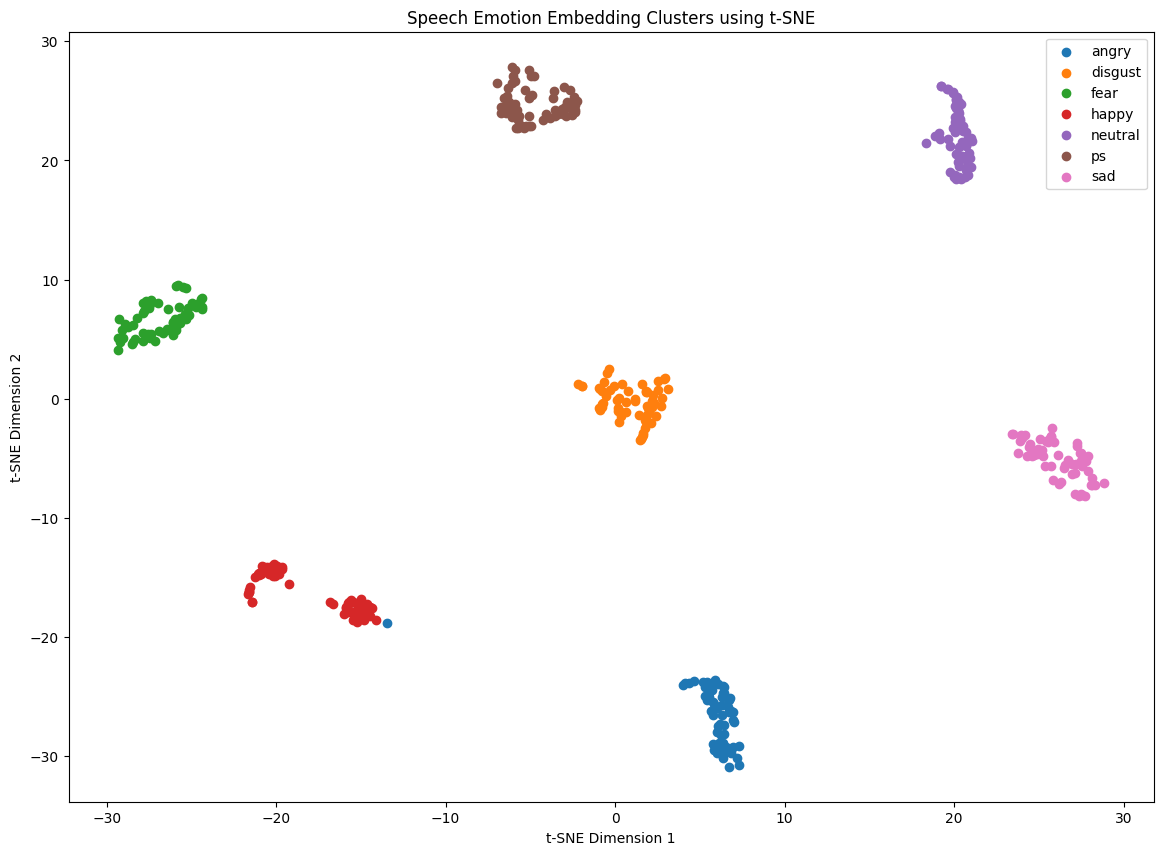

t-SNE Visualization Saved Successfully


In [42]:
tsne_plot_path = os.path.join(
    PROJECT_PATH,
    "results",
    "tsne_visualizations",
    "speech_tsne_visualization.png"
)

plt.figure(figsize=(14,10))
for label in np.unique(test_labels_array):
    indices = test_labels_array == label
    emotion_name = label_encoder.inverse_transform(
        [label]
    )[0]
    plt.scatter(
        speech_embeddings_2d[indices, 0],
        speech_embeddings_2d[indices, 1],
        label=emotion_name
    )

plt.title("Speech Emotion Embedding Clusters using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.savefig(tsne_plot_path)
plt.show()
print("t-SNE Visualization Saved Successfully")

# Saving Emotional Embeddings

The learned speech embeddings are exported for future multimodal fusion experiments.

In [43]:
embedding_export_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "speech_embeddings.npy"
)

np.save(
    embedding_export_path,
    speech_embeddings_array
)
print("Speech Embeddings Saved Successfully")

Speech Embeddings Saved Successfully


# Speech Pipeline Evaluation Summary

The speech emotion recognition system successfully demonstrated:

- robust acoustic feature learning
- strong emotional separability
- stable generalization performance
- highly discriminative emotional embeddings

The combination of:

- CNN
- BiLSTM
- Attention Mechanism

enabled highly accurate emotional classification on the TESS dataset.

# Saving Final Speech Accuracy

The final speech model accuracy is saved for later multimodal comparison analysis.

In [44]:
import os
import pickle
from sklearn.metrics import accuracy_score

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition"

speech_results_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "speech_results.pkl"
)

# Re-calculate test_accuracy to ensure it's defined in this scope
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

speech_results = {
    "speech_accuracy": test_accuracy
}
with open(
    speech_results_path,
    "wb"
) as file:
    pickle.dump(
        speech_results,
        file
    )
print("Speech Results Saved Successfully")

Speech Results Saved Successfully
